# Sentiment Analysis of Movie Reviews using RNN, LSTM, and Word2Vec Embeddings
**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Student ID:** 2431864  
**Assignment:** Part III – Natural Language Processing Task  
**Dataset:** IMDb Movie Review Dataset (Binary Sentiment Classification)

---

## 1. Setup — Imports and Dependencies

This cell imports all required libraries for the full NLP pipeline:
- **NumPy / Pandas** – data manipulation
- **Matplotlib** – plotting training curves and visualizations  
- **NLTK** – stopword removal and lemmatization  
- **TensorFlow / Keras** – deep learning model building, tokenization, and padding  
- **Scikit-learn** – evaluation metrics (accuracy, confusion matrix, classification report)  
- **WordCloud** – word frequency visualization

In [ ]:
# ============================================================
# RNN PROJECT SETUP (TEXT CLASSIFICATION PIPELINE)
# Imports, preprocessing tools, and model components setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

from collections import Counter

# ---------------- NLTK resources ----------------
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)


True

## 2. Mount Google Drive

Mounts Google Drive to access the dataset stored there. All dataset files (train/val/test CSVs) are loaded from Drive paths.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Dataset Extraction

Extracts the zipped dataset file from Google Drive into the working directory. The dataset is stored as a ZIP archive containing three CSV splits.

In [ ]:
import os
import zipfile

# ZIP file path
zip_file = "/content/drive/MyDrive/5. Movie Review Dataset-20260509T110927Z-3-001.zip"

# Extract location
extract_path = "/content/drive/MyDrive/"

# Extract dataset
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")



Dataset extracted successfully!


## 4. Dataset Loading

Loads the pre-split train, validation, and test CSV files using Pandas.  
- **Train set** – used to fit models  
- **Validation set** – used for early stopping and hyperparameter tuning  
- **Test set** – held-out evaluation set, never seen during training  

Each file contains a `review` column (raw text) and a `sentiment` column (binary label: 0 = Negative, 1 = Positive).

In [ ]:

# LOAD MOVIE REVIEW DATASET
# Reads train/validation/test CSV files and checks structure


import pandas as pd

# ---------------- Dataset paths ----------------
train_path = "/content/drive/MyDrive/5. Movie Review Dataset/train_movie_review.csv"
val_path   = "/content/drive/MyDrive/5. Movie Review Dataset/val_movie_review.csv"
test_path  = "/content/drive/MyDrive/5. Movie Review Dataset/test_movie_review.csv"

# ---------------- Load data ----------------
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

# ---------------- Basic info ----------------
print("Dataset Shapes:")
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

print("\nColumns in dataset:")
print(list(train_df.columns))

# preview
train_df.head()

Dataset Shapes:
Train: (35000, 3)
Validation: (5000, 3)
Test: (10000, 3)

Columns in dataset:
['Unnamed: 0', 'review', 'sentiment']


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


## 5. Data Cleaning — Remove Unwanted Columns

Removes any unnamed index columns that may have been introduced during CSV export. Verifies that only the expected columns (`review`, `sentiment`) are present.

In [ ]:

# CLEAN DATASET
# Removes unwanted index column and verifies text data format


# remove extra index column if it exists
for df in [train_df, val_df, test_df]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

# ---------------- Check structure ----------------
print("Cleaned Columns:")
print(list(train_df.columns))

# ---------------- Sample review ----------------
print("\nSample review text:\n")
print(train_df["review"].iloc[0][:200] + "...")

Cleaned Columns:
['review', 'sentiment']

Sample review text:

Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -...


## 6. Data Understanding and Visualization — Class Distribution

Counts the number of positive and negative reviews in the training set and plots a bar chart to visualize class balance. A balanced dataset is important to avoid biased model predictions.

Sentiment Distribution: Counter({0: 17584, 1: 17416})
Class balance ratio (Negative:Positive): 1.010


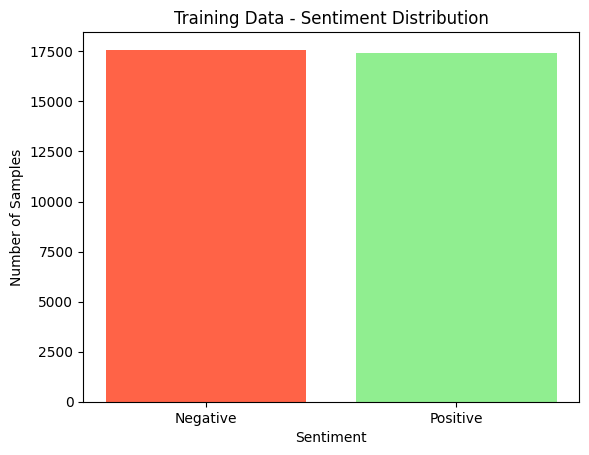

In [ ]:
# Check sentiment distribution in training data and visualize class balance

from collections import Counter
import matplotlib.pyplot as plt

target_counts = Counter(train_df["sentiment"])

print("Sentiment Distribution:", target_counts)
print(f"Class balance ratio (Negative:Positive): {target_counts[0] / target_counts[1]:.3f}")

plt.bar(
    target_counts.keys(),
    target_counts.values(),
    color=["tomato", "lightgreen"]
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("Training Data - Sentiment Distribution")
plt.xticks([0, 1], ["Negative", "Positive"])

plt.show()

## 7. Text Preprocessing — Stopword and Lemmatizer Setup

Defines the preprocessing tools:
- **Stopwords** – common words (e.g., "the", "is") are removed to reduce noise. Crucially, **negation words** (`not`, `no`, `nor`, `never`, `none`, `neither`) are **excluded from removal** to preserve sentiment-bearing signals (e.g., "not good" ≠ "good").
- **Lemmatizer** – reduces words to their base form (e.g., "running" → "run").

In [ ]:
# Define preprocessing tools for text cleaning (stopwords + lemmatization setup)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

negations = {"not", "no", "nor", "never", "none", "neither"}

stop_words = set(stopwords.words("english")) - negations

lemmatizer = WordNetLemmatizer()

## 8. Text Preprocessing — Clean Function

Defines the `preprocess_text` function that applies the full cleaning pipeline to each review:
1. Lowercase conversion
2. HTML tag removal (`<br />` etc.)
3. URL and mention removal
4. Contraction expansion (`don't` → `do not`)
5. Punctuation and number removal
6. Stopword filtering (with negation preservation)
7. Lemmatization

In [ ]:
# Clean and preprocess movie reviews for RNN model training

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)

    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
        "couldn't": "could not", "can't": "cannot", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "i'm": "i am",
        "you're": "you are", "it's": "it is", "that's": "that is",
        "n't": " not"
    }

    for c, e in contractions.items():
        text = text.replace(c, e)

    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(tokens)

# test preprocessing
sample = train_df["review"].iloc[1]
cleaned = preprocess_text(sample)

print("Original:", sample[:200])
print("\nCleaned:", cleaned[:200])

Original: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />

Cleaned: movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre


## 9. Apply Preprocessing to All Splits

Applies the `preprocess_text` function to all three data splits (train, validation, test). The cleaned text is stored in a new `cleaned_text` column.

In [ ]:
# Apply preprocessing function to train, validation, and test datasets

print("Cleaning training set...")
train_df["cleaned_text"] = train_df["review"].apply(preprocess_text)

print("Cleaning validation set...")
val_df["cleaned_text"] = val_df["review"].apply(preprocess_text)

print("Cleaning test set...")
test_df["cleaned_text"] = test_df["review"].apply(preprocess_text)

print("\nSample comparison:")
print("Original:", train_df["review"].iloc[0][:200])
print("Cleaned :", train_df["cleaned_text"].iloc[0][:200])

Cleaning training set...
Cleaning validation set...
Cleaning test set...

Sample comparison:
Original: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
Cleaned : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac


## 10. Visualization — Word Cloud

Generates a word cloud from all cleaned training reviews to visualize the most frequently occurring words. This provides a qualitative understanding of the vocabulary and dominant themes in the dataset.

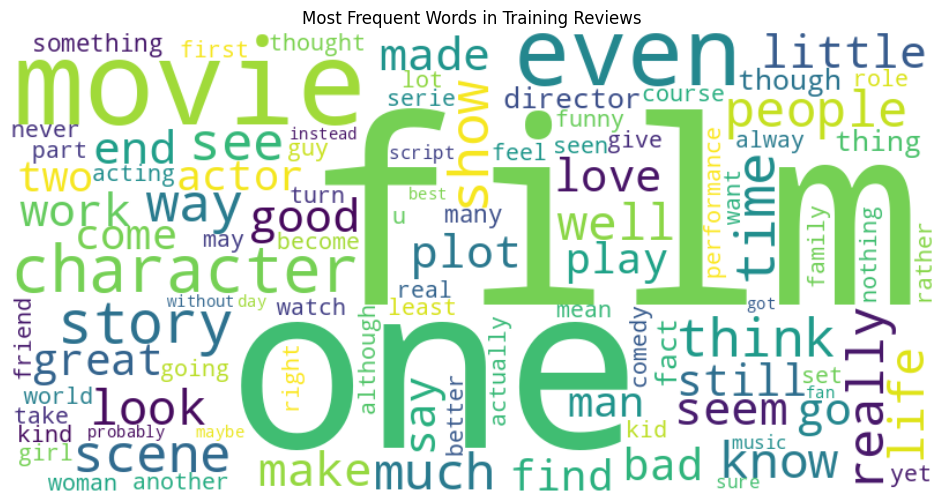

In [ ]:
# Generate word cloud to visualize most frequent words in cleaned training reviews

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = " ".join(train_df["cleaned_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Training Reviews")
plt.show()

## 11. Tokenizer Demo — Conceptual Illustration

Demonstrates how the Keras `Tokenizer` converts raw text into integer sequences using a small set of sample sentences. This is a pedagogical step to illustrate tokenization behavior before applying it to the full dataset.

In [ ]:
# Demonstration of tokenizer behavior on sample sentences before training on full dataset

from tensorflow.keras.preprocessing.text import Tokenizer

sample_texts = [
    "I love this movie!",
    "Worst film ever.",
    "Happy with the experience.",
    "Not great, not terrible.",
    "Absolutely fantastic!"
]

demo_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
demo_tokenizer.fit_on_texts(sample_texts)

demo_sequences = demo_tokenizer.texts_to_sequences(sample_texts)

print("Word Index:")
print(demo_tokenizer.word_index)

print("\nSequences:")
print(demo_sequences)

Word Index:
{'<OOV>': 1, 'not': 2, 'i': 3, 'love': 4, 'this': 5, 'movie': 6, 'worst': 7, 'film': 8, 'ever': 9, 'happy': 10, 'with': 11, 'the': 12, 'experience': 13, 'great': 14, 'terrible': 15, 'absolutely': 16, 'fantastic': 17}

Sequences:
[[3, 4, 5, 6], [7, 8, 9], [10, 11, 12, 13], [2, 14, 2, 15], [16, 17]]


## 12. Tokenization — Build Vocabulary and Convert Text to Sequences

Fits a Keras `Tokenizer` on the training set with a vocabulary cap of 20,000 words. Converts all three data splits into integer sequences. The `<OOV>` (out-of-vocabulary) token handles unseen words during inference.

In [ ]:
# Build tokenizer on training data and convert text into integer sequences for RNN input

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["cleaned_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["cleaned_text"])
X_val_seq   = tokenizer.texts_to_sequences(val_df["cleaned_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["cleaned_text"])

print("Vocabulary size:", len(tokenizer.word_index))
print("Sample review word count:", len(train_df["cleaned_text"].iloc[100].split()))

Vocabulary size: 122386
Sample review word count: 40


## 13. Sequence Padding

Analyzes sequence lengths across the training set and applies **percentile-based padding** (95th percentile) to determine `max_len`. This avoids excessively long sequences from outlier reviews while preserving most of the vocabulary context.

All sequences are padded/truncated using `post` strategy for consistent RNN input shape.

In [ ]:
# Analyze sequence lengths and apply padding for RNN input preparation

from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Max sequence length before padding: {max(seq_lengths)}")

print("\nSequence length statistics:")
print(f"Min    : {np.min(seq_lengths)}")
print(f"Max    : {np.max(seq_lengths)}")
print(f"Mean   : {np.mean(seq_lengths):.0f}")
print(f"Median : {np.median(seq_lengths):.0f}")
print(f"95th % : {np.percentile(seq_lengths, 95):.0f}")
print(f"99th % : {np.percentile(seq_lengths, 99):.0f}")

max_len = int(np.percentile(seq_lengths, 95))
print(f"\nSelected max_len: {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

y_train = np.array(train_df["sentiment"].values)
y_val   = np.array(val_df["sentiment"].values)
y_test  = np.array(test_df["sentiment"].values)

print("\nFinal shapes:")
print(f"X_train: {X_train_pad.shape}")
print(f"X_val  : {X_val_pad.shape}")
print(f"X_test : {X_test_pad.shape}")

Max sequence length before padding: 1433

Sequence length statistics:
Min    : 4
Max    : 1433
Mean   : 120
Median : 90
95th % : 309
99th % : 467

Selected max_len: 309

Final shapes:
X_train: (35000, 309)
X_val  : (5000, 309)
X_test : (10000, 309)


## 14. Visualization — Sequence Length Distribution

Plots a histogram of sequence lengths in the training set. The 95th percentile cutoff (shown as a red dashed line) is used as `max_len`, ensuring that 95% of reviews are fully preserved while controlling memory usage.

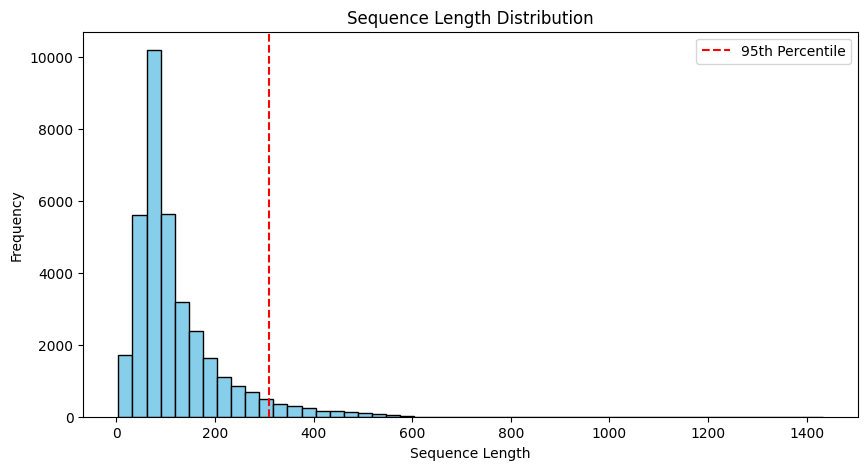

In [ ]:
# Visualize distribution of sequence lengths to decide optimal padding size

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

plt.hist(seq_lengths, bins=50, color="skyblue", edgecolor="black")

plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

p95 = np.percentile(seq_lengths, 95)
plt.axvline(p95, color="red", linestyle="dashed", label="95th Percentile")

plt.legend()
plt.show()

## 15. Class Balance Verification and OOV Rate Analysis

Verifies that class balance is consistent across all three splits. Also computes the **OOV (out-of-vocabulary) rate** on the test set — the percentage of tokens that were not seen during tokenizer fitting. A high OOV rate would indicate vocabulary mismatch.

In [ ]:
# Check class balance across splits and compute OOV (out-of-vocabulary) rate

from collections import Counter
import numpy as np

train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

print("Class distribution:")
print(f"Train → Negative: {train_counts[0]} | Positive: {train_counts[1]}")
print(f"Val   → Negative: {val_counts[0]} | Positive: {val_counts[1]}")
print(f"Test  → Negative: {test_counts[0]} | Positive: {test_counts[1]}")

oov_index = tokenizer.word_index.get("<OOV>", 1)

total_tokens = X_test_pad[X_test_pad != 0].size
oov_tokens   = (X_test_pad == oov_index).sum()

print("\nOOV analysis (Test set):")
print(f"OOV tokens: {oov_tokens}")
print(f"Total tokens: {total_tokens}")
print(f"OOV rate: {oov_tokens / total_tokens * 100:.2f}%")

Class distribution:
Train → Negative: 17584 | Positive: 17416
Val   → Negative: 2455 | Positive: 2545
Test  → Negative: 4961 | Positive: 5039

OOV analysis (Test set):
OOV tokens: 62789
Total tokens: 1161029
OOV rate: 5.41%


## 16. Model 1 — Simple RNN with Trainable Embedding

Builds the first model using a **SimpleRNN** architecture:
- `Embedding(vocab_size, 128)` – learns word representations from scratch
- `SimpleRNN(64)` – processes the sequence left-to-right with a hidden state
- `Dense(1, sigmoid)` – outputs a probability for binary classification

**Loss:** Binary cross-entropy | **Optimizer:** Adam

In [ ]:
# Build a Simple RNN model for binary sentiment classification

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128
hidden_units = 64

print("Model: Simple RNN for Sentiment Classification")

model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(hidden_units),
    Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

Model: Simple RNN for Sentiment Classification


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,677,953 (59.81 MB)

 Trainable params: 15,677,953 (59.81 MB)

 Non-trainable params: 0 (0.00 B)

## 17. Model 2 — LSTM with Trainable Embedding

Builds the second model using an **LSTM** architecture:
- `Embedding(vocab_size, 128)` – same as Model 1 (trainable)
- `LSTM(64)` – captures long-range dependencies using gating mechanisms (input, forget, output gates), overcoming the vanishing gradient problem of SimpleRNN
- `Dense(1, sigmoid)` – binary classification output

**Loss:** Binary cross-entropy | **Optimizer:** Adam

In [ ]:
# Build an LSTM model for sentiment classification

print("Model: LSTM for Sentiment Classification")

model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(hidden_units),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: LSTM for Sentiment Classification


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,715,009 (59.95 MB)

 Trainable params: 15,715,009 (59.95 MB)

 Non-trainable params: 0 (0.00 B)

## 18. Training — Simple RNN

Trains Model 1 (Simple RNN) for up to 10 epochs with:
- **EarlyStopping** (patience=4) – stops training if validation loss does not improve, restores best weights
- **ModelCheckpoint** – saves the best model weights to disk based on validation loss

In [ ]:
# Train Simple RNN model with checkpointing and early stopping

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_rnn = ModelCheckpoint(
    "simple_rnn_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5013 - loss: 0.6969
Epoch 1: val_loss improved from None to 0.69390, saving model to simple_rnn_best.keras

Epoch 1: finished saving model to simple_rnn_best.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - accuracy: 0.4996 - loss: 0.6961 - val_accuracy: 0.4940 - val_loss: 0.6939
Epoch 2/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5060 - loss: 0.6930
Epoch 2: val_loss did not improve from 0.69390
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5104 - loss: 0.6926 - val_accuracy: 0.5208 - val_loss: 0.6972
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5257 - loss: 0.6837
Epoch 3: val_loss did not improve from 0.69390
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.5216 - loss: 0.6825 - val_accuracy: 0.4934 - val_loss: 0.6983
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5234 - loss: 0.6674
Epoch 4: val_loss did not improve from 0.69

## 19. Evaluation Utility Function — `model_diagnosis`

Defines a reusable evaluation function that for any model:
1. Generates predictions on the test set
2. Reports prediction statistics and threshold analysis
3. Computes accuracy, classification report (precision, recall, F1), and confusion matrix
4. Plots training vs. validation loss and accuracy curves

In [ ]:
# Evaluate model performance: predictions, metrics, confusion matrix, and training curves

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

def model_diagnosis(model, history, X_test_pad, y_test, model_name="Model"):

    y_pred_proba = model.predict(X_test_pad, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

    print(f"Diagnosis Report: {model_name}")

    print("\nPrediction statistics:")
    print(f"Min  : {y_pred_proba.min():.4f}")
    print(f"Max  : {y_pred_proba.max():.4f}")
    print(f"Mean : {y_pred_proba.mean():.4f}")
    print(f"Std  : {y_pred_proba.std():.4f}")

    print("\nThreshold analysis:")
    print(f"{'Threshold':<12}{'Positive%':<12}{'Negative%':<12}")

    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        preds = (y_pred_proba > t).flatten()
        pos_pct = preds.mean() * 100
        neg_pct = 100 - pos_pct
        print(f"{t:<12}{pos_pct:<12.1f}{neg_pct:<12.1f}")

    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("            Pred Neg   Pred Pos")
    print(f"True Neg     {cm[0,0]:<8}    {cm[0,1]}")
    print(f"True Pos     {cm[1,0]:<8}    {cm[1,1]}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return acc

## 20. Evaluation — Simple RNN Results

Runs full evaluation on the Simple RNN model. Reports accuracy, per-class precision/recall/F1, confusion matrix, and training curves.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Diagnosis Report: Simple RNN

Prediction statistics:
Min  : 0.4612
Max  : 0.5528
Mean : 0.4891
Std  : 0.0065

Threshold analysis:
Threshold   Positive%   Negative%   
0.3         100.0       0.0         
0.4         100.0       0.0         
0.5         4.0         96.0        
0.6         0.0         100.0       
0.7         0.0         100.0       

Accuracy: 0.4994

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.96      0.66      4961
    Positive       0.54      0.04      0.08      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.37     10000
weighted avg       0.52      0.50      0.37     10000


Confusion Matrix:
            Pred Neg   Pred Pos
True Neg     4778        183
True Pos     4823        216


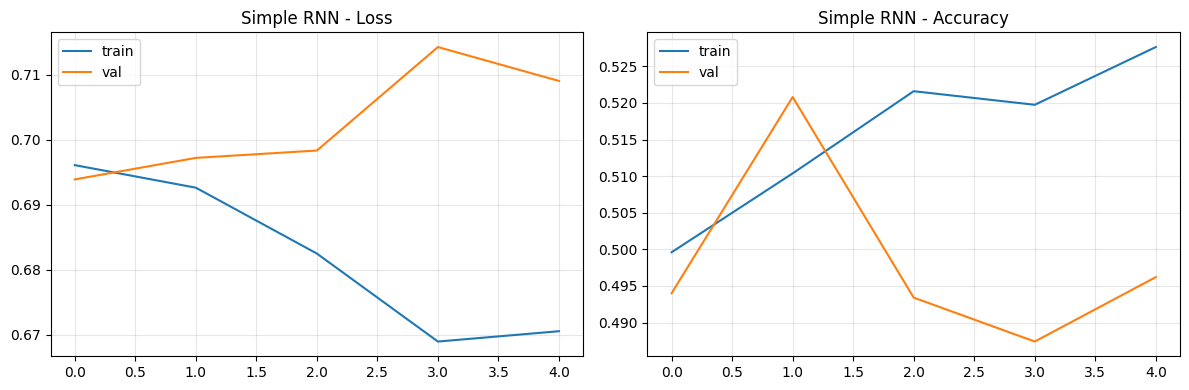

In [ ]:
# Run full evaluation + diagnostics on Simple RNN model

acc_rnn = model_diagnosis(
    model_rnn,
    history_rnn,
    X_test_pad,
    y_test,
    model_name="Simple RNN"
)

## 21. Training — LSTM

Trains Model 2 (LSTM) for up to 10 epochs using the same callback configuration as the Simple RNN. EarlyStopping monitors validation loss with patience=4.

In [ ]:
# Train LSTM model with checkpointing and early stopping

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_lstm = ModelCheckpoint(
    "lstm_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_lstm, early_stop]
)

Epoch 1/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5037 - loss: 0.6936
Epoch 1: val_loss improved from None to 0.69332, saving model to lstm_best_model.keras

Epoch 1: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.5010 - loss: 0.6933 - val_accuracy: 0.4984 - val_loss: 0.6933
Epoch 2/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5107 - loss: 0.6835
Epoch 2: val_loss improved from 0.69332 to 0.69280, saving model to lstm_best_model.keras

Epoch 2: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5131 - loss: 0.6808 - val_accuracy: 0.5054 - val_loss: 0.6928
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5913 - loss: 0.6166
Epoch 3: val_loss improved from 0.69280 to 0.36255, saving model to lstm_best_model.keras

Epoch 3: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accura

## 22. Evaluation — LSTM Results

Runs full evaluation on the LSTM model. Results are compared against Simple RNN in the model comparison section below.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Diagnosis Report: LSTM

Prediction statistics:
Min  : 0.0010
Max  : 0.9997
Mean : 0.5075
Std  : 0.4159

Threshold analysis:
Threshold   Positive%   Negative%   
0.3         56.3        43.7        
0.4         53.3        46.7        
0.5         50.7        49.3        
0.6         48.2        51.8        
0.7         45.5        54.5        

Accuracy: 0.8820

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4961
    Positive       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Confusion Matrix:
            Pred Neg   Pred Pos
True Neg     4353        608
True Pos     572         4467


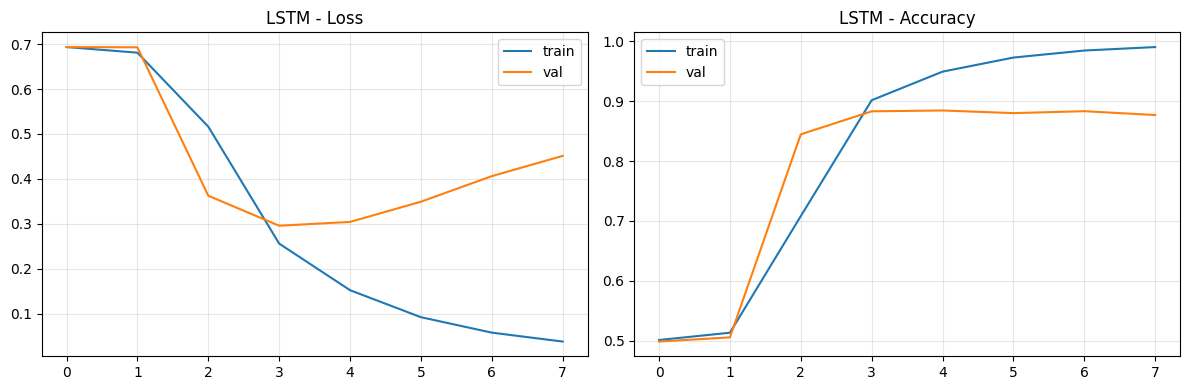

In [ ]:
# Run full evaluation + diagnostics on LSTM model

acc_lstm = model_diagnosis(
    model_lstm,
    history_lstm,
    X_test_pad,
    y_test,
    model_name="LSTM"
)

## 23. Install Gensim

Installs the `gensim` library required to download and use pretrained word embeddings (GloVe/Word2Vec) via the `gensim.downloader` API.

In [ ]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.7 MB/s eta 0:00:00


## 24. Load Pretrained GloVe Embeddings (Word2Vec)

Loads **GloVe (Global Vectors for Word Representation)** embeddings trained on Wikipedia and Gigaword corpus with 100-dimensional vectors (`glove-wiki-gigaword-100`). These pretrained embeddings encode rich semantic relationships between words learned from a large external corpus.

In [ ]:
# Load pretrained GloVe embeddings for embedding layer initialization

import gensim.downloader as api

print("Loading pretrained word embeddings (GloVe)...")

word2vec_model = api.load("glove-wiki-gigaword-100")

print(f"Loaded embeddings successfully. Vocabulary size: {len(word2vec_model)}")

Loading pretrained word embeddings (GloVe)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded embeddings successfully. Vocabulary size: 400000


## 25. Build Embedding Matrix

Constructs a `(vocab_size × 100)` embedding matrix by mapping each word in the tokenizer vocabulary to its pretrained GloVe vector. Words not found in GloVe are initialized with a random normal vector. The memory used by the GloVe model is released after matrix construction.

In [ ]:
# Build embedding matrix using pretrained GloVe vectors + random init for missing words

import numpy as np
import gc

embedding_dim_w2v = 100  # matches glove-wiki-gigaword-100

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

hit, miss = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue

    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        hit += 1
    else:
        embedding_matrix[idx] = np.random.normal(
            scale=0.6,
            size=(embedding_dim_w2v,)
        )
        miss += 1

print("Embedding coverage:")
print(f"Found words   : {hit}")
print(f"Missing words : {miss}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Free memory after building matrix
del word2vec_model
gc.collect()

print("Pretrained embeddings removed from memory")

Embedding coverage:
Found words   : 60037
Missing words : 62349
Embedding matrix shape: (122387, 100)
Pretrained embeddings removed from memory


## 26. Model 3 — LSTM with Pretrained Word2Vec (GloVe) Embeddings

Builds the third model with the pretrained GloVe embedding layer:
- `Embedding(weights=[embedding_matrix], trainable=False)` – loads pretrained vectors, **frozen** during training to preserve learned representations
- `LSTM(64)` – same LSTM architecture as Model 2
- `Dense(1, sigmoid)` – binary classification output

The key difference from Model 2 is the **fixed pretrained embedding** vs. random trainable embedding.

In [ ]:
# Build LSTM model using pretrained GloVe embeddings (frozen embedding layer)

print("Model: LSTM with pretrained embeddings (GloVe)")

model_lstm_w2v = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(hidden_units),
    Dense(1, activation="sigmoid")
])

model_lstm_w2v.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm_w2v.summary()

Model: LSTM with pretrained embeddings (GloVe)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 309, 100)       │    12,238,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,281,005 (46.85 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 12,238,700 (46.69 MB)

## 27. Training — LSTM with Pretrained Embeddings

Trains Model 3 (LSTM + GloVe) for up to 10 epochs using the same EarlyStopping and ModelCheckpoint strategy. Since embeddings are frozen, the model learns only the LSTM and Dense layer weights.

In [ ]:
# Train LSTM model with pretrained embeddings (GloVe) + early stopping + checkpointing

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_w2v = ModelCheckpoint(
    "lstm_w2v_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_w2v, early_stop]
)

Epoch 1/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5084 - loss: 0.6919
Epoch 1: val_loss improved from None to 0.69190, saving model to lstm_w2v_best_model.keras

Epoch 1: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5129 - loss: 0.6909 - val_accuracy: 0.5114 - val_loss: 0.6919
Epoch 2/10
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5226 - loss: 0.6849
Epoch 2: val_loss did not improve from 0.69190
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.5567 - loss: 0.6723 - val_accuracy: 0.4952 - val_loss: 0.6954
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5065 - loss: 0.6908
Epoch 3: val_loss improved from 0.69190 to 0.68742, saving model to lstm_w2v_best_model.keras

Epoch 3: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5250 - loss: 0.6866 - val_accuracy: 0.5172 - val_loss: 0.6874
Epoch 4/10
1094/

## 28. Evaluation — LSTM + Word2Vec Results

Runs full evaluation on the LSTM + GloVe model. This is the best-performing model and is used for the error analysis and inference steps below.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Diagnosis Report: LSTM + Word2Vec

Prediction statistics:
Min  : 0.0085
Max  : 0.9922
Mean : 0.5029
Std  : 0.3946

Threshold analysis:
Threshold   Positive%   Negative%   
0.3         57.0        43.0        
0.4         53.2        46.8        
0.5         50.1        49.9        
0.6         47.0        53.0        
0.7         43.9        56.1        

Accuracy: 0.8619

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      4961
    Positive       0.87      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Confusion Matrix:
            Pred Neg   Pred Pos
True Neg     4287        674
True Pos     707         4332


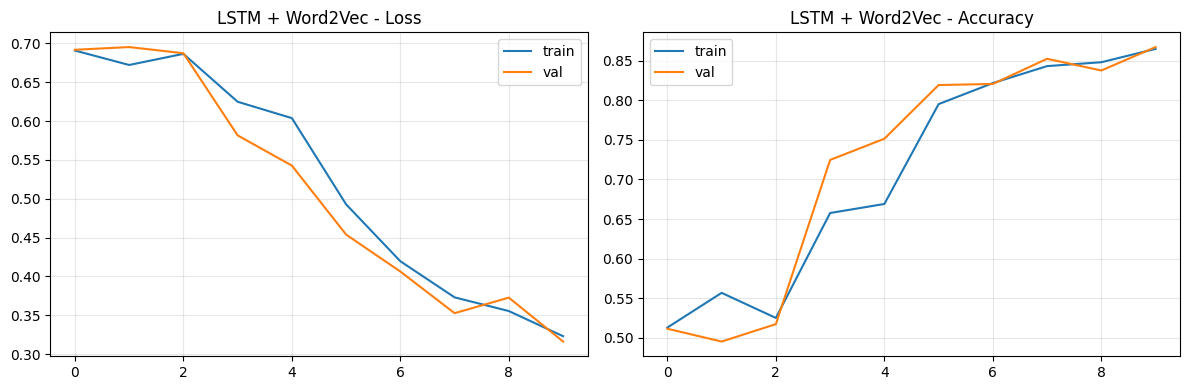

In [ ]:
# Evaluate LSTM model with pretrained embeddings using full diagnosis pipeline

acc_w2v = model_diagnosis(
    model_lstm_w2v,
    history_lstm_w2v,
    X_test_pad,
    y_test,
    model_name="LSTM + Word2Vec"
)

## 29. Model Comparison — RNN vs LSTM vs LSTM + Word2Vec

Generates a final comparison table and side-by-side plots of validation loss and accuracy across all three models. This allows direct assessment of:
- The benefit of LSTM over Simple RNN
- The impact of pretrained embeddings (Word2Vec/GloVe) on model performance

FINAL MODEL COMPARISON
          Model Accuracy
     Simple RNN   0.4994
           LSTM   0.8820
LSTM + Word2Vec   0.8619


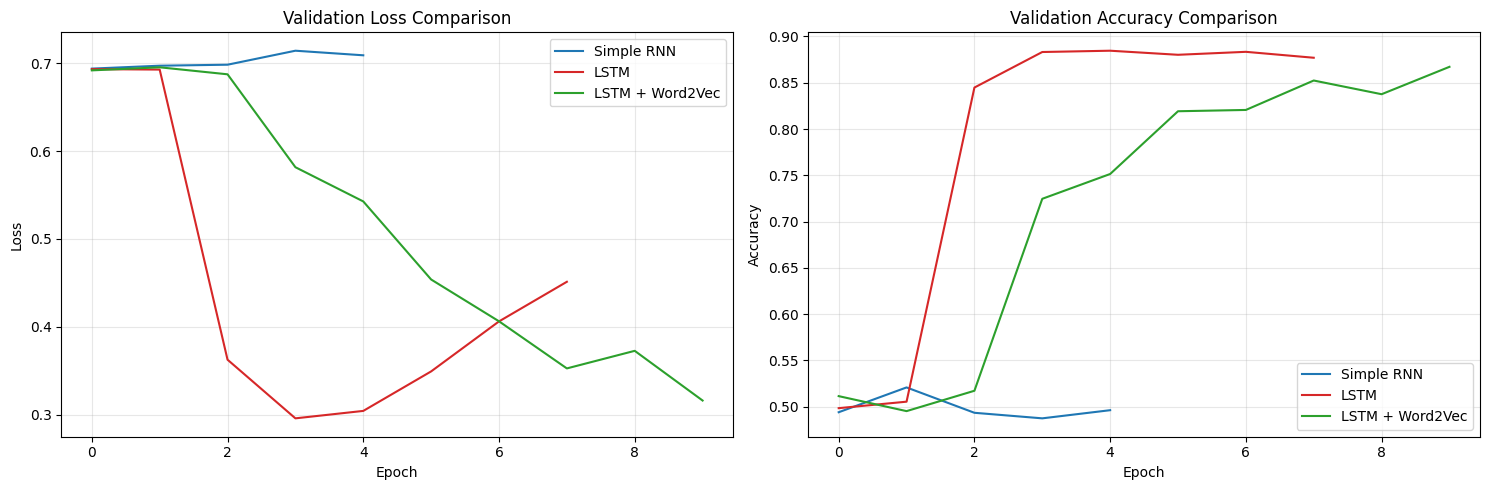

In [ ]:
# Compare performance of Simple RNN, LSTM, and LSTM with pretrained embeddings

import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "LSTM + Word2Vec"],
    "Accuracy": [f"{acc_rnn:.4f}", f"{acc_lstm:.4f}", f"{acc_w2v:.4f}"]
})

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_rnn.history["val_loss"], label="Simple RNN", color="#1f77b4")
axes[0].plot(history_lstm.history["val_loss"], label="LSTM", color="#d62728")
axes[0].plot(history_lstm_w2v.history["val_loss"], label="LSTM + Word2Vec", color="#2ca02c")
axes[0].set_title("Validation Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history["val_accuracy"], label="Simple RNN", color="#1f77b4")
axes[1].plot(history_lstm.history["val_accuracy"], label="LSTM", color="#d62728")
axes[1].plot(history_lstm_w2v.history["val_accuracy"], label="LSTM + Word2Vec", color="#2ca02c")
axes[1].set_title("Validation Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 30. Error Analysis

Identifies misclassified samples from the test set using the best model (LSTM + Word2Vec). For each misclassified review:
- True and predicted labels are shown
- Confidence score is reported
- Original and cleaned review text is displayed

**Possible reasons for errors:**
- **Sarcasm and irony** – e.g., "What a masterpiece" said negatively
- **Mixed sentiment** – reviews with both positive and negative statements
- **Negation in complex structures** – e.g., "I can't say I didn't enjoy it"
- **Domain-specific vocabulary** – words absent from GloVe vocabulary

In [ ]:
# Error analysis using best model (LSTM + pretrained embeddings)

y_pred_proba = model_lstm_w2v.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

misclassified_indices = np.where(y_pred != y_test)[0]

print(f"Misclassified samples: {len(misclassified_indices)} / {len(y_test)}")

print("\nMisclassification analysis (sample cases):")

for i, idx in enumerate(misclassified_indices[:3]):
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if y_pred[idx] == 1 else "Negative"
    confidence = float(y_pred_proba[idx][0])

    print(f"\nCase {i+1}")
    print(f"True label : {true_label}")
    print(f"Predicted  : {pred_label} (confidence {confidence:.4f})")

    print("\nOriginal review:")
    print(test_df["review"].iloc[idx][:300])

    print("\nCleaned review:")
    print(test_df["cleaned_text"].iloc[idx][:300])

Misclassified samples: 1381 / 10000

Misclassification analysis (sample cases):

Case 1
True label : Positive
Predicted  : Negative (confidence 0.0677)

Original review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 

Cleaned review:
really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf not lex luger main event yokozuna time ok huge fat man v strong man glad time changed terrible main event like every match luger terrible match card razor ramon v ted dibiase st

Case 2
True label : Positive
Predicted  : Negative (confidence 0.0860)

Original review:
Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was go

## 31. Real-Time Sentiment Prediction

Defines a `predict_sentiment` function that takes any raw text string, preprocesses it through the full pipeline, and returns the predicted sentiment label with a confidence score. Tested on three custom reviews to verify end-to-end inference.

In [ ]:
# Predict sentiment for custom input reviews using trained model

def predict_sentiment(text, model):
    cleaned_text = preprocess_text(text)

    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    prob = model.predict(padded, verbose=0)[0][0]

    if prob > 0.5:
        return "Positive", float(prob)
    else:
        return "Negative", float(1 - prob)

# Sample inference tests
test_reviews = [
    "This movie was absolutely amazing! Great acting and storyline.",
    "Worst film I have ever seen. Total waste of time.",
    "It was okay, nothing special but not terrible either."
]

print("Sample Predictions (LSTM + Word2Vec):\n")

for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model_lstm_w2v)

    print(f"Review: {review[:80]}")
    print(f"Prediction: {sentiment} (confidence: {confidence:.4f})\n")

Sample Predictions (LSTM + Word2Vec):

Review: This movie was absolutely amazing! Great acting and storyline.
Prediction: Positive (confidence: 0.9476)

Review: Worst film I have ever seen. Total waste of time.
Prediction: Negative (confidence: 0.9674)

Review: It was okay, nothing special but not terrible either.
Prediction: Negative (confidence: 0.9637)

